Q2 skeleton:
This skeleton intends to give students some hints. You could try to use the skelton code provided to implement Q2, but feel free to use your own implmentation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
import torchvision
import torchvision.transforms as transforms

# Q1 : Downloading and Formatting Data.

def load_data():
    print("Downloading and processing MNIST data...")

    train_dataset = torchvision.datasets.MNIST(root='./data', train=True,
                                               download=True, transform=transforms.ToTensor())
    test_dataset = torchvision.datasets.MNIST(root='./data', train=False,
                                              download=True, transform=transforms.ToTensor())

    # Flatten images: (N, 28, 28) -> (N, 784)
    X_train = train_dataset.data.numpy().reshape(-1, 784) / 255.0
    y_train = train_dataset.targets.numpy()

    X_test = test_dataset.data.numpy().reshape(-1, 784) / 255.0
    y_test = test_dataset.targets.numpy()

    return X_train, y_train, X_test, y_test

def one_hot_encode(y, num_classes=10):
    # Create One-Hot vector
    N = y.shape[0]
    y_oh = np.zeros((N, num_classes))
    y_oh[np.arange(N), y] = 1
    return y_oh


# Q2 : Minibatch SGD Implementation

#initialize W for random numbers for the first epoch
def initialize_weights(num_classes, input_size):
    np.random.seed(42)
    return np.random.randn(num_classes, input_size) * 0.01

def forward_pass(X, W):
    # f(x) = Wx
    # X: (Batch, 784), W: (10, 784) -> Output: (Batch, 10)
    return np.dot(X, W.T)

def compute_loss(y_pred, y_true, W, reg_lambda):
    # Quadratic Loss: 0.5 * ||y - Wx||^2 + 0.5 * lambda * ||W||^2
    batch_size = y_true.shape[0]
    diff = y_true - y_pred
    data_loss = 0.5 * np.sum(diff**2) / batch_size
    reg_loss = 0.5 * reg_lambda * np.sum(W**2)
    return data_loss + reg_loss

def compute_gradient(X, y_pred, y_true, W, reg_lambda):
    # Gradient of Data Term: - (y - Wx) * x^T
    # Gradient of Reg Term: lambda * W
    batch_size = X.shape[0]
    diff = y_pred - y_true # (Batch, 10)

    # Gradient: (10, 784)
    # Transpose math: (10, B) @ (B, 784) -> (10, 784)
    grad_data = np.dot(diff.T, X) / batch_size
    grad_reg = reg_lambda * W

    return grad_data + grad_reg

def sgd(W, grad_W, learning_rate):
    return W - learning_rate * grad_W

def train_classifier(X_train, y_train, X_val, y_val, num_classes, input_size, batch_size, num_epochs, learning_rate, reg_lambda):

    # 1. Initialize Weights
    W = initialize_weights(num_classes, input_size)

    # Format targets to one-hot
    y_train_oh = one_hot_encode(y_train, num_classes)
    y_val_oh = one_hot_encode(y_val, num_classes)

    # Training Loop
    N = X_train.shape[0]
    iterations_per_epoch = N // batch_size
    total_iterations = num_epochs * iterations_per_epoch

    loss_history = []
    acc_history = []

    start_time = time.time()

    for t in range(total_iterations):
        # (i) Select B numbers uniformly at random
        indices = np.random.choice(N, batch_size, replace=True)
        X_batch = X_train[indices]
        y_batch_oh = y_train_oh[indices]

        # Forward
        y_pred = forward_pass(X_batch, W)

        # (ii) Calculate Gradient
        grad = compute_gradient(X_batch, y_pred, y_batch_oh, W, reg_lambda)

        # (iii) Update W
        W = sgd(W, grad, learning_rate)

        if t % 100 == 0:
            # Calculate loss on the current batch
            l = compute_loss(y_pred, y_batch_oh, W, reg_lambda)
            loss_history.append(l)

            # Calculate validation accuracy
            val_scores = forward_pass(X_val, W)
            val_preds = np.argmax(val_scores, axis=1)
            acc = np.mean(val_preds == y_val)
            acc_history.append(acc)

    total_time = time.time() - start_time
    print(f"Training completed in {total_time:.2f}s. Final Acc: {acc_history[-1]:.4f}")

    return W, loss_history, acc_history, total_time


# Load Data once for all experiments
X_train, y_train, X_test, y_test = load_data()



100%|██████████| 9.91M/9.91M [00:00<00:00, 39.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.08MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.75MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.23MB/s]


<>:35: SyntaxWarning: invalid escape sequence '\e'
<>:35: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-2802013844.py:35: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(x_axis, losses, label=f'B={B} ($\eta$={lr})')


Running B=1, LR=0.001, Epochs=1...
Training completed in 19.48s. Final Acc: 0.8429
Running B=10, LR=0.01, Epochs=1...
Training completed in 1.97s. Final Acc: 0.8378
Running B=100, LR=0.05, Epochs=9...
Training completed in 6.16s. Final Acc: 0.7110
Running B=1000, LR=0.5, Epochs=84...


/tmp/ipython-input-2869343377.py:51: RuntimeWarning: overflow encountered in square
  data_loss = 0.5 * np.sum(diff**2) / batch_size
/tmp/ipython-input-2869343377.py:52: RuntimeWarning: overflow encountered in square
  reg_loss = 0.5 * reg_lambda * np.sum(W**2)


Training completed in 34.75s. Final Acc: 0.0980


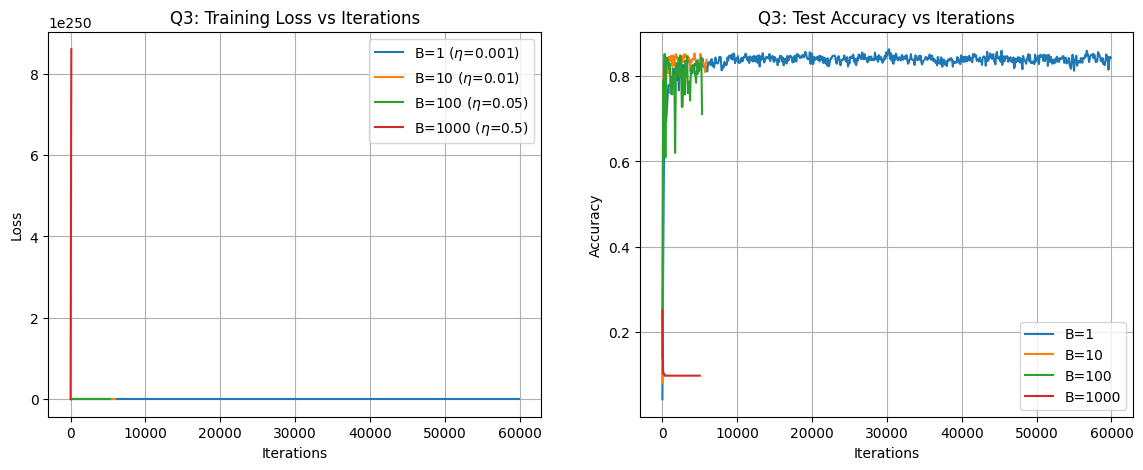

In [ ]:
# Q3: Batch Size Experiments

batch_sizes = [1, 10, 100, 1000]
results = {}

# Hyperparameters
reg_lambda = 0.1
# Adjust epochs to ensure roughly same number of updates.
ITR = 5000

plt.figure(figsize=(14, 5))

# Manual tuning of LR for stability
lrs = {1: 0.001, 10: 0.01, 100: 0.05, 1000: 0.5}

for i, B in enumerate(batch_sizes):
    lr = lrs[B]
    # Calculate num_epochs to match fixed ITR
    # ITR = epochs * (N/B) -> epochs = ITR / (N/B) = ITR * B / N
    epochs = int(np.ceil(ITR / (60000 / B)))
    if epochs < 1: epochs = 1

    print(f"Running B={B}, LR={lr}, Epochs={epochs}...")

    _, losses, accs, duration = train_classifier(
        X_train, y_train, X_test, y_test,
        10, 784, B, epochs, lr, reg_lambda
    )

    # Store for plotting
    x_axis = np.arange(len(losses)) * 100 # stored every 100 iters

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(x_axis, losses, label=f'B={B} ($\eta$={lr})')

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(x_axis, accs, label=f'B={B}')

plt.subplot(1, 2, 1)
plt.title("Q3: Training Loss vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.title("Q3: Test Accuracy vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()



**For Q4 : Comment on the role of batch size.**

Smaller batch sizes (B=1) result in 'noisy' convergence.

Larger batch sizes (B=1000) are computationally more efficient per epoch due to vectorization. They also allow for larger learning rates and smoother and faster convergence.


--- Q5 Dataset Size Experiments ---
Training completed in 0.12s. Final Acc: 0.1533
N'=100 -> Final Acc: 0.1533
Training completed in 0.70s. Final Acc: 0.7661
N'=500 -> Final Acc: 0.7661
Training completed in 0.86s. Final Acc: 0.7989
N'=1000 -> Final Acc: 0.7989
Training completed in 3.52s. Final Acc: 0.7584
N'=10000 -> Final Acc: 0.7584


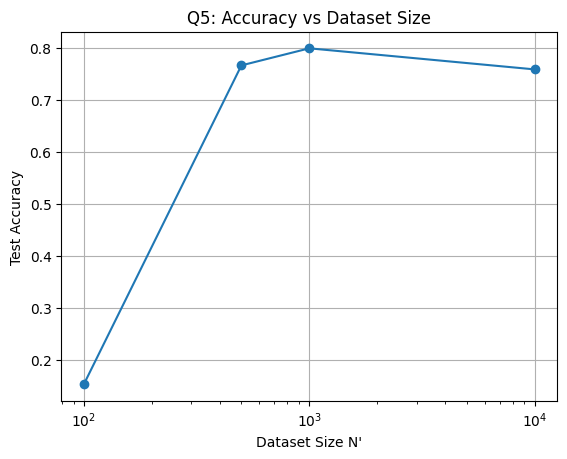

In [ ]:
# Q5: Dataset Size Experiments

dataset_sizes = [100, 500, 1000, 10000]
B = 100
lr = 0.05
reg_lambda = 0.1
epochs = 50
final_accs = []

print("\n--- Q5 Dataset Size Experiments ---")
for N_prime in dataset_sizes:
    # Subsample without replacement
    indices = np.random.choice(X_train.shape[0], N_prime, replace=False)
    X_sub = X_train[indices]
    y_sub = y_train[indices]

    _, _, accs, _ = train_classifier(
        X_sub, y_sub, X_test, y_test,
        10, 784, B, epochs, lr, reg_lambda
    )
    final_accs.append(accs[-1])
    print(f"N'={N_prime} -> Final Acc: {accs[-1]:.4f}")

plt.figure()
plt.plot(dataset_sizes, final_accs, marker='o')
plt.xscale('log')
plt.xlabel("Dataset Size N'")
plt.ylabel("Test Accuracy")
plt.title("Q5: Accuracy vs Dataset Size")
plt.grid(True)
plt.show()


**Comment for Q5**

Accuracy improves with dataset size.

With only 100 examples, the model overfits and fails to learn robust features.

With 10,000 examples, it generalizes well.


--- Q6: PyTorch Comparison ---
Training completed in 0.91s. Final Acc: 0.7590


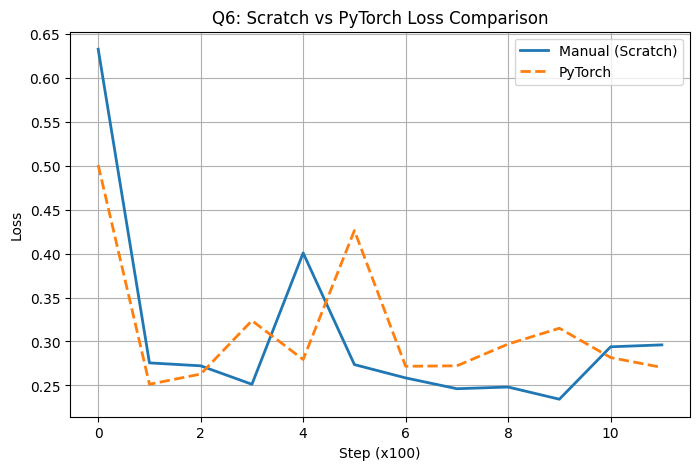

In [ ]:

# Q6: PyTorch Verification

import torch.nn as nn
import torch.optim as optim

def run_pytorch_comparison():
    print("\n--- Q6: PyTorch Comparison ---")
    B = 100
    lr = 0.05
    reg_lambda = 0.1
    ITR = 1000

    # 1. Custom Implementation Run
    # Calculate epochs needed for ITR
    epochs_needed = int(ITR / (60000/B)) + 1
    W_custom, loss_custom, _, _ = train_classifier(
        X_train, y_train, X_test, y_test,
        10, 784, B, epochs_needed, lr, reg_lambda
    )

    # 2. PyTorch Implementation
    # Convert data
    X_pt = torch.tensor(X_train, dtype=torch.float32)
    # Target for MSE must be One-Hot Float
    y_oh = one_hot_encode(y_train)
    y_pt = torch.tensor(y_oh, dtype=torch.float32)

    # Model: Linear (No bias to match scratch)
    model = nn.Linear(784, 10, bias=False)
    # Init weights to 0
    with torch.no_grad():
        model.weight.fill_(0.0)

    # Optimizer
    optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=reg_lambda)

    loss_pt = []

    # Training Loop
    model.train()

    for t in range(len(loss_custom) * 100): # Match duration
        idx = torch.randint(0, 60000, (B,))
        x_b = X_pt[idx]
        y_b = y_pt[idx]

        # Forward
        pred = model(x_b)

        # Loss: 0.5 * MSE
        # PyTorch MSELoss is mean by default. We want 0.5 * sum((y-y_hat)^2) / B
        mse = 0.5 * torch.sum((y_b - pred)**2) / B

        # Backward
        optimizer.zero_grad()
        mse.backward()
        optimizer.step()

        if t % 100 == 0:
            reg = 0.5 * reg_lambda * torch.sum(model.weight**2)
            total_loss = mse + reg
            loss_pt.append(total_loss.item())

    # Plot Comparison
    plt.figure(figsize=(8,5))
    plt.plot(loss_custom[:len(loss_pt)], label='Manual (Scratch)', linewidth=2)
    plt.plot(loss_pt, label='PyTorch', linestyle='--', linewidth=2)
    plt.title("Q6: Scratch vs PyTorch Loss Comparison")
    plt.xlabel("Step (x100)")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

run_pytorch_comparison()